# 1. Разведочный анализ данных (EDA)

**Датасет**: BRFSS 2015 (Diabetes Binary, 50/50 split)  
**Цель**: Изучить распределения, выявить артефакты, сформировать гипотезы для отбора признаков.  
**Инструменты**: `pandas`, `seaborn`, `matplotlib`

In [6]:
import sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))
from config import DATA_RAW, DATASET_FILENAME, FEATURE_LABELS, CATEGORY_MAPS, TARGET_COL

# Настройки визуализации
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Загрузка
df = pd.read_csv(DATA_RAW / DATASET_FILENAME)
print(f"✅ Загружено: {df.shape[0]} строк, {df.shape[1]} колонок")

✅ Загружено: 70692 строк, 22 колонок


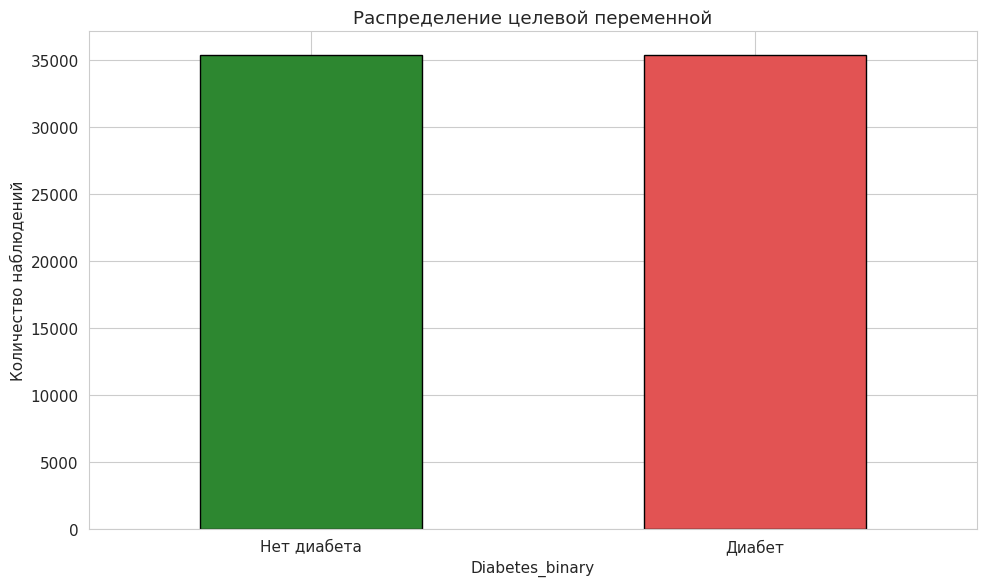

In [ ]:
plt.figure()
df[TARGET_COL].value_counts().sort_index().plot(
    kind='bar', color=['#2D8730', '#E25353'], edgecolor='black'
)
plt.xticks([0, 1], ['Нет диабета', 'Диабет'], rotation=0)
plt.ylabel('Количество наблюдений')
plt.title('Распределение целевой переменной')
plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=300)
plt.show()

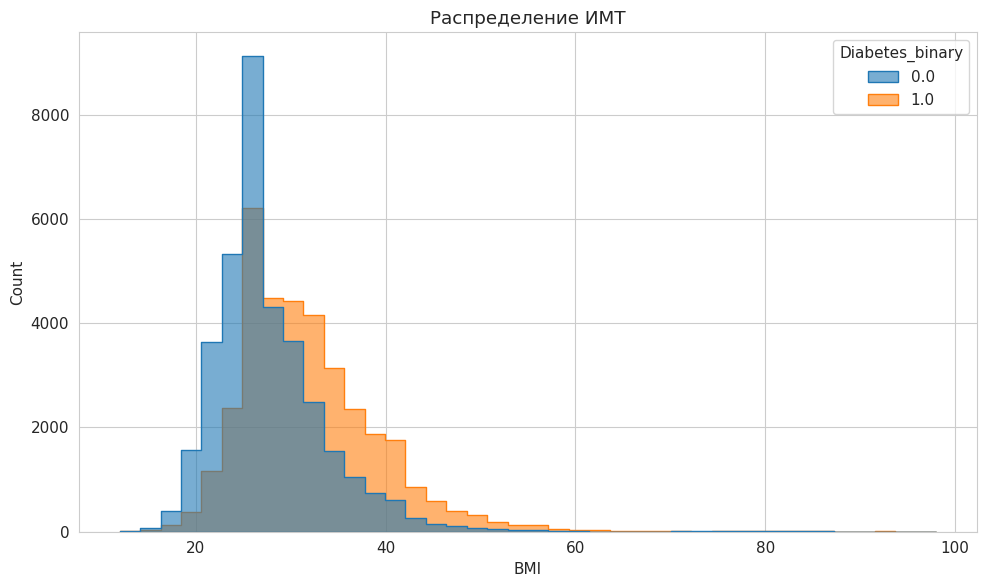

In [8]:
numeric = ['BMI']
for col in numeric:
    plt.figure()
    sns.histplot(data=df, x=col, hue=TARGET_COL, bins=40, alpha=0.6, element='step')
    plt.title(f'Распределение {FEATURE_LABELS[col]}')
    plt.tight_layout()
    plt.savefig(f'figures/dist_{col}.png', dpi=300)
    plt.show()

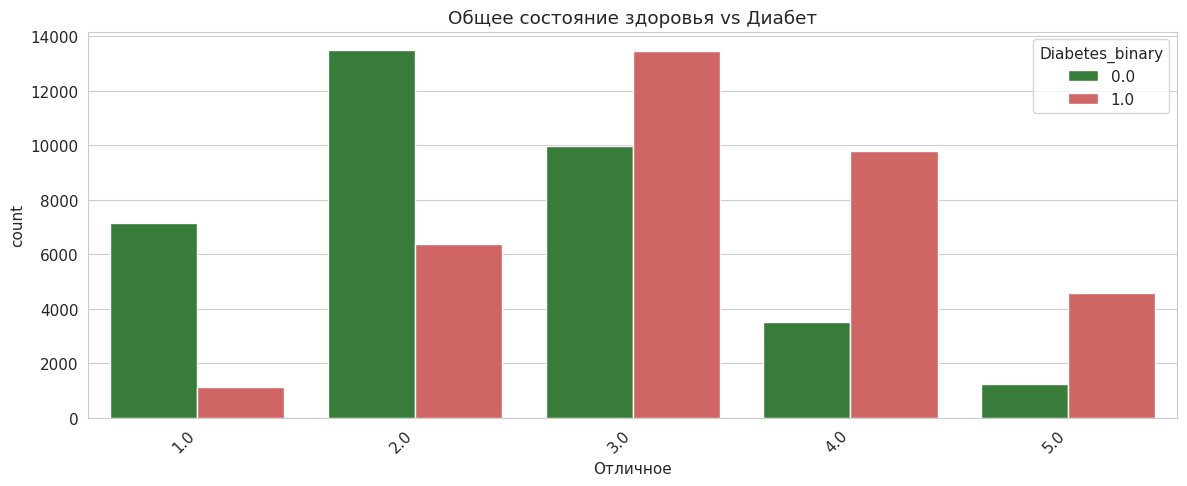

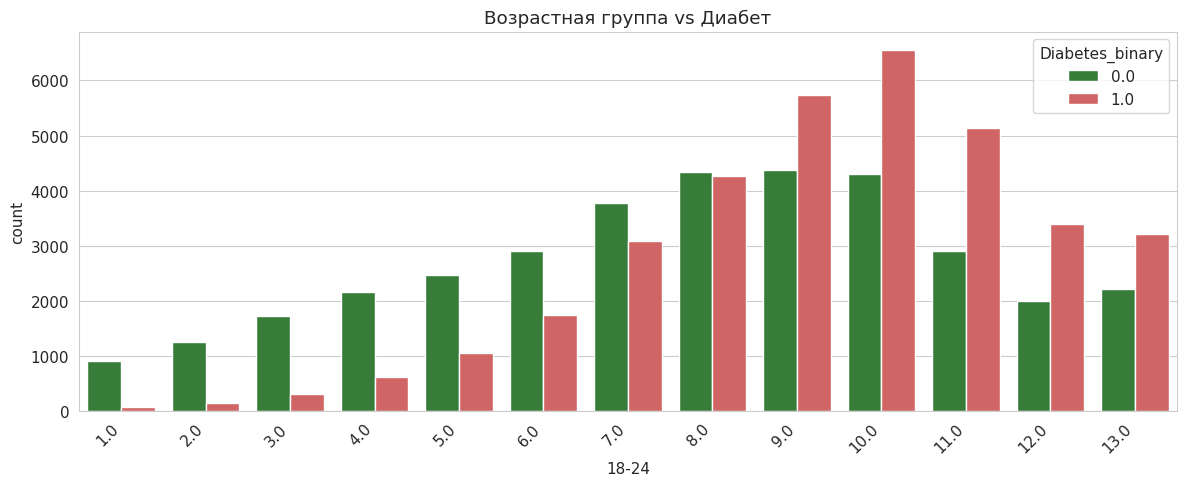

In [9]:
for col in ['GenHlth', 'Age']:
    plt.figure(figsize=(12, 5))
    order = sorted(df[col].dropna().unique())
    sns.countplot(data=df, x=col, hue=TARGET_COL, order=order, palette=['#2D8730', '#E25353'])
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(CATEGORY_MAPS.get(col, {}).get(1, col) if col in CATEGORY_MAPS else col)
    plt.title(f'{FEATURE_LABELS[col]} vs Диабет')
    plt.tight_layout()
    plt.savefig(f'figures/cat_{col}.png', dpi=300)
    plt.show()

### Выводы по EDA:
1. Датасет сбалансирован (50/50), что упрощает обучение, но требует калибровки вероятностей при деплое.
2. `GenHlth` показывает чёткую градацию: чем хуже самооценка здоровья, тем выше доля диабета.
3. `BMI` имеет правостороннее смещение; пациенты с диабетом в среднем имеют более высокий ИМТ.
4. Артефакты (`77/777/99/999`) отсутствуют — датасет уже очищен.
5. Для дальнейшего моделирования отобраны 7 признаков на основе визуального анализа и предметной области.